## IT SERVICES — WHICH SKILLS ARE ACTUALLY IN DEMAND?

## PART 1 — IMPORT LIBRARIES

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import itertools
import warnings

# Scikit-learn imports for Machine Learning section
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# Configure display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

## PART 2 — LOAD DATASET

In [80]:
# Load the dataset
df = pd.read_csv('IT_Services_Synthetic_Job_Skills_35000.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Dataset shape: (35000, 8)

First 5 rows of the dataset:
      Job_ID        Date                  Role Company_Type         Location Experience                                             Skills             Salary_Range
0  JOB117814  2025-04-16          Data Analyst   Consulting    New York, USA  5-8 years  Docker, Excel, Kubernetes, Linux, MySQL, Redis...  ₹22.4-30.6 LPA (equiv.)
1  JOB106858  2023-02-09          Data Analyst      FinTech     Kochi, India    Fresher                                  Excel, MySQL, SQL             ₹3.7-4.8 LPA
2  JOB107673  2025-02-08  Full Stack Developer      Telecom  Berlin, Germany  3-5 years  Git, GitHub, JavaScript, Next.js, RAG, React, ...  ₹18.5-23.6 LPA (equiv.)
3  JOB109705  2022-05-03          Data Analyst      Startup  Berlin, Germany  1-2 years                   MySQL, Power BI, SQL, Statistics  ₹12.1-14.8 LPA (equiv.)
4  JOB114304  2025-11-25     Software Engineer  IT Services    New York, USA   8+ years      AWS, Git, JavaScript, LLM, Post

## PART 3 — BASIC DATA CLEANING

In [82]:
# 1. Standardize column names
df_cleaned = df.copy()
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace(' ', '_')

# 2. Clean 'Role' column
df_cleaned['role'] = df_cleaned['role'].str.lower().str.strip()
df_cleaned['role_cleaned'] = df_cleaned['role'].replace({
    'software developer': 'software engineer',
    'ml engineer': 'ml engineer',
    'data scientist': 'data scientist',
    'devops engineer': 'devops engineer',
    'full stack developer': 'full stack developer',
    'cloud engineer': 'cloud engineer',
    'cybersecurity engineer': 'cybersecurity engineer',
    'data analyst': 'data analyst'
})

# 3. Clean 'Location' column
df_cleaned['location'] = df_cleaned['location'].str.lower().str.strip()

# 4. Clean 'Experience' column
# Map experience ranges to categories. 'Other' will catch any unhandled values.
def map_experience(exp):
    if 'fresher' in exp.lower():
        return 'Fresher'
    elif '1-2' in exp or '1 year' in exp or '2 years' in exp:
        return 'Junior'
    elif '3-5' in exp or '3 years' in exp or '4 years' in exp or '5 years' in exp:
        return 'Mid-Level'
    elif '5-8' in exp or '6 years' in exp or '7 years' in exp or '8 years' in exp:
        return 'Senior'
    elif '8+' in exp or '9 years' in exp or '10+' in exp or 'lead' in exp.lower() or 'principal' in exp.lower():
        return 'Lead/Principal'
    else:
        return 'Other'

df_cleaned['experience_category'] = df_cleaned['experience'].apply(map_experience)

# 5. Clean 'Skills' column
# Convert skills string to a list of cleaned skills (lowercase, stripped)
df_cleaned['skills_list'] = df_cleaned['skills'].apply(lambda x:
    [s.lower().strip() for s in str(x).split(',') if s.strip()])

# Add a skill count column for later analysis
df_cleaned['skill_count'] = df_cleaned['skills_list'].apply(len)

# 6. Extract and clean Salary_Range
# Define a function to extract numerical salary values (LPA assumed)
import re

def clean_salary(salary_range):
    # Remove common text and symbols, keep only numbers and hyphens/dots
    # This handles cases like ' (equiv.)' which might cause issues
    cleaned_string = salary_range.replace('₹', '').replace('LPA', '').replace('(equiv.)', '').strip()

    # Use regex to find all numbers (integers or floats)
    numbers = re.findall(r'\d+\.?\d*', cleaned_string)

    if len(numbers) == 2:
        try:
            low = float(numbers[0])
            high = float(numbers[1])
            return low * 100000, high * 100000
        except ValueError:
            return np.nan, np.nan
    elif len(numbers) == 1:
        try:
            val = float(numbers[0])
            return val * 100000, val * 100000
        except ValueError:
            return np.nan, np.nan
    else:
        return np.nan, np.nan

df_cleaned[['salary_low', 'salary_high']] = df_cleaned['salary_range'].apply(lambda x: pd.Series(clean_salary(x)))
df_cleaned['salary_mid'] = (df_cleaned['salary_low'] + df_cleaned['salary_high']) / 2


# 7. Convert 'Date' column to datetime and extract year/month
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
df_cleaned['year'] = df_cleaned['date'].dt.year
df_cleaned['month'] = df_cleaned['date'].dt.month
df_cleaned['year_month'] = df_cleaned['date'].dt.to_period('M').astype(str)

# Display cleaned dataframe info and head to verify
print(f"Cleaned Dataset shape: {df_cleaned.shape}")
print("\nFirst 5 rows of the cleaned dataset:")
print(df_cleaned.head())

Cleaned Dataset shape: (35000, 18)

First 5 rows of the cleaned dataset:
      job_id       date                  role company_type         location experience                                             skills             salary_range          role_cleaned experience_category                                        skills_list  skill_count  salary_low  salary_high  salary_mid  year  month year_month
0  JOB117814 2025-04-16          data analyst   Consulting    new york, usa  5-8 years  Docker, Excel, Kubernetes, Linux, MySQL, Redis...  ₹22.4-30.6 LPA (equiv.)          data analyst              Senior  [docker, excel, kubernetes, linux, mysql, redi...            7   2240000.0    3060000.0   2650000.0  2025      4    2025-04
1  JOB106858 2023-02-09          data analyst      FinTech     kochi, india    Fresher                                  Excel, MySQL, SQL             ₹3.7-4.8 LPA          data analyst             Fresher                                [excel, mysql, sql]            

## PART 4 — BASIC DATA ANALYSIS

In [84]:
print("### 4.1 Job Distribution by Role ###")
role_distribution = df_cleaned['role_cleaned'].value_counts().reset_index()
role_distribution.columns = ['Role', 'Number of Jobs']
role_distribution['Percentage'] = (role_distribution['Number of Jobs'] / len(df_cleaned)) * 100
print(role_distribution)

print("\n### 4.2 Job Distribution by Experience Category ###")
experience_distribution = df_cleaned['experience_category'].value_counts().reset_index()
experience_distribution.columns = ['Experience_Category', 'Number of Jobs']
experience_distribution['Percentage'] = (experience_distribution['Number of Jobs'] / len(df_cleaned)) * 100
# Order by experience level for better readability
experience_order = ['Fresher', 'Junior', 'Mid-Level', 'Senior', 'Lead/Principal', 'Other']
experience_distribution['Experience_Category'] = pd.Categorical(experience_distribution['Experience_Category'], categories=experience_order, ordered=True)
experience_distribution = experience_distribution.sort_values('Experience_Category').reset_index(drop=True)
print(experience_distribution)

print("\n### 4.3 Job Distribution by Company Type ###")
company_type_distribution = df_cleaned['company_type'].value_counts().reset_index()
company_type_distribution.columns = ['Company_Type', 'Number of Jobs']
company_type_distribution['Percentage'] = (company_type_distribution['Number of Jobs'] / len(df_cleaned)) * 100
print(company_type_distribution)

print("\n### 4.4 Job Distribution by Location (Top 10) ###")
top_10_locations = df_cleaned['location'].value_counts().head(10).reset_index()
top_10_locations.columns = ['Location', 'Number of Jobs']
print(top_10_locations)

print("\n### 4.5 Average Salary by Role ###")
salary_by_role = df_cleaned.groupby('role_cleaned')['salary_mid'].mean().sort_values(ascending=False).reset_index()
salary_by_role.columns = ['Role', 'Average Salary (INR)']
print(salary_by_role)

print("\n### 4.6 Average Salary by Experience Category ###")
salary_by_experience = df_cleaned.groupby('experience_category')['salary_mid'].mean().reset_index()
salary_by_experience['experience_category'] = pd.Categorical(salary_by_experience['experience_category'], categories=experience_order, ordered=True)
salary_by_experience = salary_by_experience.sort_values('experience_category').reset_index(drop=True)
salary_by_experience.columns = ['Experience_Category', 'Average Salary (INR)']
print(salary_by_experience)

print("\n### 4.7 Average Salary by Location (Top 10) ###")
salary_by_location = df_cleaned.groupby('location')['salary_mid'].mean().sort_values(ascending=False).head(10).reset_index()
salary_by_location.columns = ['Location', 'Average Salary (INR)']
print(salary_by_location)

### 4.1 Job Distribution by Role ###
                     Role  Number of Jobs  Percentage
0       software engineer            9854   28.154286
1            data analyst            5166   14.760000
2          data scientist            4197   11.991429
3          cloud engineer            4188   11.965714
4         devops engineer            3542   10.120000
5    full stack developer            3433    9.808571
6             ml engineer            2882    8.234286
7  cybersecurity engineer            1738    4.965714

### 4.2 Job Distribution by Experience Category ###
  Experience_Category  Number of Jobs  Percentage
0             Fresher            6456   18.445714
1              Junior            8887   25.391429
2           Mid-Level           10098   28.851429
3              Senior            6966   19.902857
4      Lead/Principal            2593    7.408571

### 4.3 Job Distribution by Company Type ###
       Company_Type  Number of Jobs  Percentage
0       IT Services           

## PART 5 — MOST IN-DEMAND SKILLS

In [85]:
# Flatten the list of skills and count occurrences
all_skills = df_cleaned['skills_list'].explode()
skill_counts = all_skills.value_counts()

# Convert to DataFrame for better presentation
skill_demand = skill_counts.reset_index()
skill_demand.columns = ['Skill', 'Job_Count']

# Calculate percentage of jobs requiring each skill
skill_demand['Percentage'] = (skill_demand['Job_Count'] / len(df_cleaned)) * 100

# Add rank
skill_demand['Rank'] = skill_demand['Job_Count'].rank(ascending=False).astype(int)

# Display top 15 most in-demand skills
top_15_skills = skill_demand.head(15)
print("### Top 15 Most In-Demand Skills ###")
print(top_15_skills)

# Store overall skill percentages for later use
overall_skill_percentages = skill_demand.set_index('Skill')['Percentage']

### Top 15 Most In-Demand Skills ###
               Skill  Job_Count  Percentage  Rank
0                git      16482   47.091429     1
1         javascript      14470   41.342857     2
2             docker      12492   35.691429     3
3             python      12439   35.540000     4
4                sql      11440   32.685714     5
5             github       7957   22.734286     6
6   machine learning       7469   21.340000     7
7              linux       7167   20.477143     8
8                aws       6953   19.865714     9
9           rest api       5705   16.300000    10
10             react       4680   13.371429    11
11             ci/cd       4396   12.560000    12
12        postgresql       4112   11.748571    13
13              java       4094   11.697143    14
14        kubernetes       3827   10.934286    15


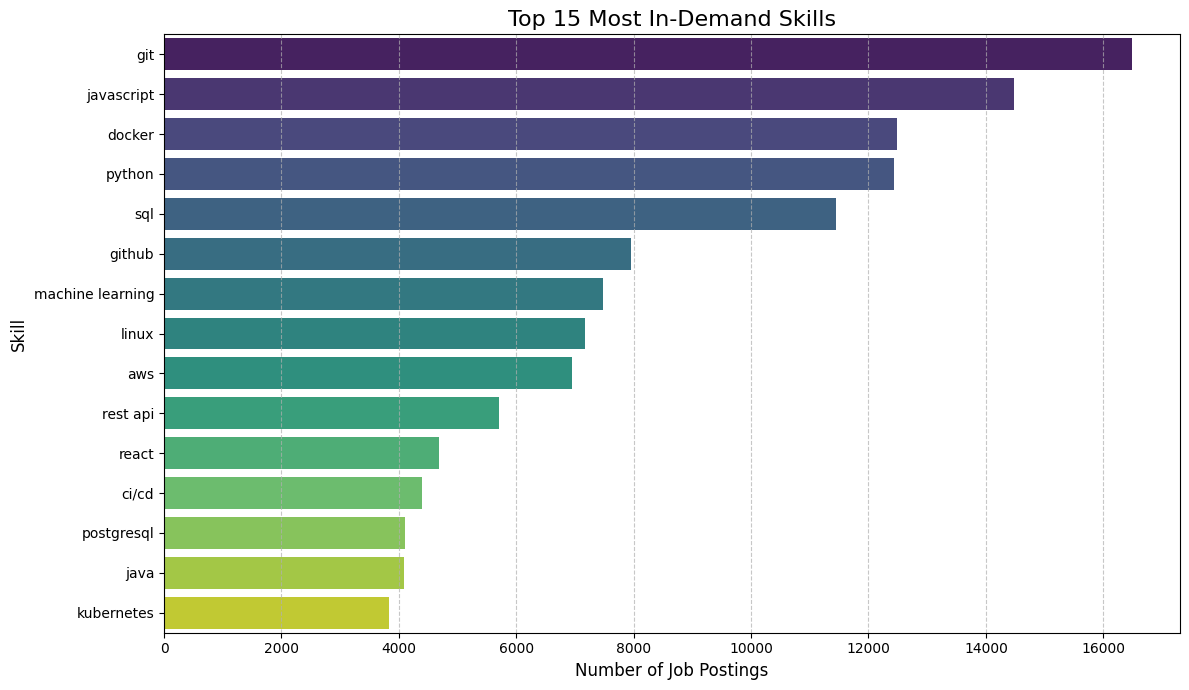

### Explanation of Most In-Demand Skills ###
The bar chart above illustrates the top 15 skills most frequently mentioned in job advertisements within our synthetic dataset.
Skills like 'Git', 'JavaScript', 'Docker', and 'Python' appear to be consistently highly demanded, indicating their foundational importance across various IT roles.
This visualization quickly highlights the essential technical competencies that are widely sought after by employers in this dataset.


In [96]:
# Create a horizontal bar chart for Top 15 Most In-Demand Skills (Visualization 1)
plt.figure(figsize=(12, 7))
sns.barplot(x='Job_Count', y='Skill', data=top_15_skills, palette='viridis')
plt.title('Top 15 Most In-Demand Skills', fontsize=16)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("### Explanation of Most In-Demand Skills ###")
print("The bar chart above illustrates the top 15 skills most frequently mentioned in job advertisements within our synthetic dataset.")
print("Skills like 'Git', 'JavaScript', 'Docker', and 'Python' appear to be consistently highly demanded, indicating their foundational importance across various IT roles.")
print("This visualization quickly highlights the essential technical competencies that are widely sought after by employers in this dataset.")

## PART 6 — SKILLS BY ROLE

In [86]:
major_roles = df_cleaned['role_cleaned'].unique()
role_skill_demand = {}

for role in major_roles:
    # Filter dataframe for the specific role
    role_jobs = df_cleaned[df_cleaned['role_cleaned'] == role]
    total_role_jobs = len(role_jobs)

    # Flatten the skills list for the current role and count occurrences
    if total_role_jobs > 0:
        skills_in_role = role_jobs['skills_list'].explode()
        skill_counts_role = skills_in_role.value_counts()

        # Calculate percentage of jobs within this role that demand each skill
        role_skill_percentages = (skill_counts_role / total_role_jobs) * 100
        role_skill_demand[role] = role_skill_percentages.to_dict()
    else:
        role_skill_demand[role] = {}

# Convert to DataFrame for easier analysis and display
role_skill_df = pd.DataFrame(role_skill_demand).fillna(0)

# Display top 5 skills for each major role
print("### Top 5 Skills for Each Major Role (Percentage of jobs demanding the skill) ###")
for role in major_roles:
    print(f"\n--- {role.title()} ---")
    top_skills_for_role = role_skill_df[role].nlargest(5)
    print(top_skills_for_role.round(2))

# Also show average skill count by role
skill_count_by_role = df_cleaned.groupby('role_cleaned')['skill_count'].agg(['mean', 'median', 'min', 'max'])
skill_count_by_role.columns = ['Average_Skill_Count', 'Median_Skill_Count', 'Min_Skill_Count', 'Max_Skill_Count']
skill_count_by_role = skill_count_by_role.sort_values(by='Average_Skill_Count', ascending=False)
print("\n### Average Skill Count by Role ###")
print(skill_count_by_role.round(2))

### Top 5 Skills for Each Major Role (Percentage of jobs demanding the skill) ###

--- Data Analyst ---
sql         100.00
excel        33.57
python       29.91
git          29.83
power bi     27.06
Name: data analyst, dtype: float64

--- Full Stack Developer ---
react         100.00
javascript     85.67
git            32.89
github         27.64
rest api       24.58
Name: full stack developer, dtype: float64

--- Software Engineer ---
javascript    100.00
git            86.72
github         32.63
rest api       25.92
sql            25.31
Name: software engineer, dtype: float64

--- Cloud Engineer ---
docker        100.00
aws            89.64
git            33.86
linux          29.66
kubernetes     26.86
Name: cloud engineer, dtype: float64

--- Data Scientist ---
machine learning    100.00
python               86.49
git                  28.02
sql                  27.78
statistics           24.71
Name: data scientist, dtype: float64

--- Ml Engineer ---
machine learning    100.00
python

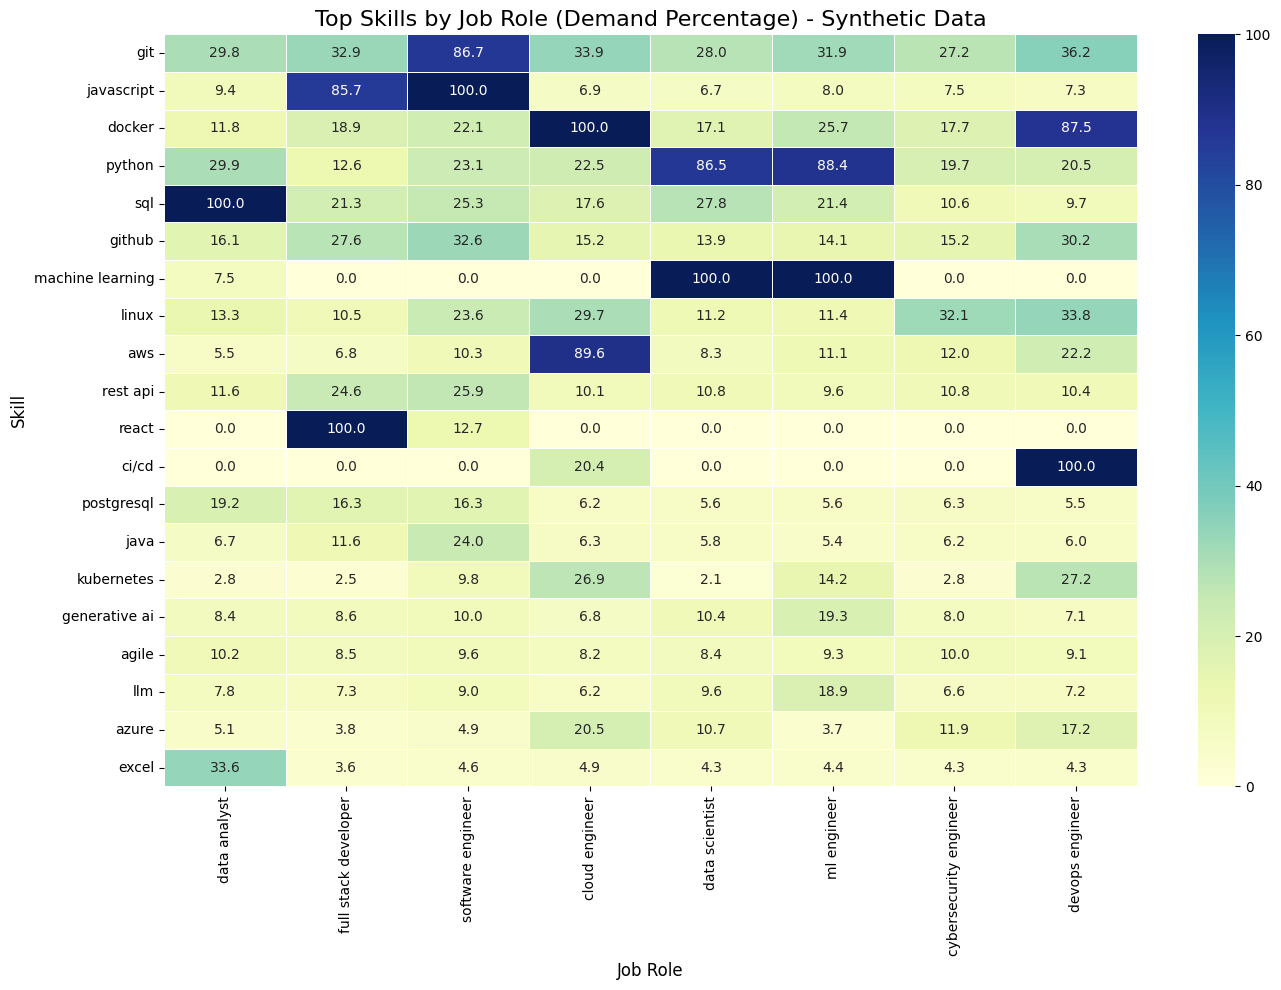

### Explanation of Skills by Job Role ###
The heatmap above displays the demand percentage of the top 20 overall skills across different major job roles.
Darker shades indicate higher demand for a skill within a particular role. For example, 'SQL' is highly demanded for Data Analyst and Data Scientist roles, while 'Docker' is crucial for Cloud Engineer and DevOps Engineer roles.
This visualization clearly shows how skill requirements are specialized for each job role, helping to differentiate the technical profiles of various IT professions in our synthetic data.


In [97]:
# Create a heatmap for Skills by Job Role (Visualization 2)

# Select top N skills overall to ensure a readable heatmap
top_n_skills = 20 # Can be adjusted based on clarity
heatmap_skills = overall_skill_percentages.nlargest(top_n_skills).index.tolist()

# Filter the role_skill_df to include only these top N skills and the major roles
heatmap_data = role_skill_df.loc[heatmap_skills, major_roles]

# Sort skills by overall percentage for consistent visualization if desired
heatmap_data = heatmap_data.reindex(heatmap_skills)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.round(1), annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Top Skills by Job Role (Demand Percentage) - Synthetic Data', fontsize=16)
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.tight_layout()
plt.show()

print("### Explanation of Skills by Job Role ###")
print("The heatmap above displays the demand percentage of the top 20 overall skills across different major job roles.")
print("Darker shades indicate higher demand for a skill within a particular role. For example, 'SQL' is highly demanded for Data Analyst and Data Scientist roles, while 'Docker' is crucial for Cloud Engineer and DevOps Engineer roles.")
print("This visualization clearly shows how skill requirements are specialized for each job role, helping to differentiate the technical profiles of various IT professions in our synthetic data.")

## PART 7 — SKILLS THAT OCCUR TOGETHER

In [87]:
# Generate all unique pairs of skills from the skills_list column
pair_counts = Counter()
for skills in df_cleaned['skills_list']:
    # Sort skills to ensure (a,b) and (b,a) are counted as the same pair
    for skill1, skill2 in itertools.combinations(sorted(set(skills)), 2):
        pair_counts[(skill1, skill2)] += 1

# Convert to DataFrame for easier analysis
co_occurrence_df = pd.DataFrame(pair_counts.most_common(), columns=['Skill_Pair', 'Jobs_Together'])

# Split the 'Skill_Pair' tuple into two separate columns
co_occurrence_df[['Skill 1', 'Skill 2']] = pd.DataFrame(co_occurrence_df['Skill_Pair'].tolist(), index=co_occurrence_df.index)
co_occurrence_df.drop('Skill_Pair', axis=1, inplace=True)

# Calculate percentage of jobs where these skills co-occur
co_occurrence_df['Percentage'] = (co_occurrence_df['Jobs_Together'] / len(df_cleaned)) * 100

# Display top 15 co-occurring skill pairs
top_15_co_occurrence = co_occurrence_df.head(15)
print("### Top 15 Most Co-occurring Skill Pairs ###")
print(top_15_co_occurrence)

# For visualization, let's create a co-occurrence matrix for the top N skills
# First, identify the most frequent skills overall to limit the matrix size
common_top_skills = skill_demand['Skill'].head(20).tolist()

# Filter skills_list to only include these top skills
filtered_skills_list = df_cleaned['skills_list'].apply(lambda x: [s for s in x if s in common_top_skills])

# Recalculate co-occurrences for these filtered skills
co_occurrence_matrix_counts = Counter()
for skills in filtered_skills_list:
    for skill1, skill2 in itertools.combinations(sorted(set(skills)), 2):
        co_occurrence_matrix_counts[(skill1, skill2)] += 1

# Create a DataFrame for the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=common_top_skills, columns=common_top_skills)
for (s1, s2), count in co_occurrence_matrix_counts.items():
    co_occurrence_matrix.loc[s1, s2] = count
    co_occurrence_matrix.loc[s2, s1] = count # Since it's symmetric

# Convert counts to percentages for the heatmap
co_occurrence_percentage_matrix = (co_occurrence_matrix.div(len(df_cleaned), axis=0)) * 100

print("\n### Co-occurrence Matrix (Top 20 Skills - Percentage) ###")
print(co_occurrence_percentage_matrix.round(2).head())


### Top 15 Most Co-occurring Skill Pairs ###
    Jobs_Together           Skill 1     Skill 2  Percentage
0           10025               git  javascript   28.642857
1            6270  machine learning      python   17.914286
2            5273            docker         git   15.065714
3            5023               git      python   14.351429
4            4898               aws      docker   13.994286
5            4809               git         sql   13.740000
6            4309            github  javascript   12.311429
7            4188        javascript       react   11.965714
8            4181               git      github   11.945714
9            3975            python         sql   11.357143
10           3952             ci/cd      docker   11.291429
11           3805        javascript         sql   10.871429
12           3654            docker      python   10.440000
13           3538               git       linux   10.108571
14           3438        javascript    rest api    9.82

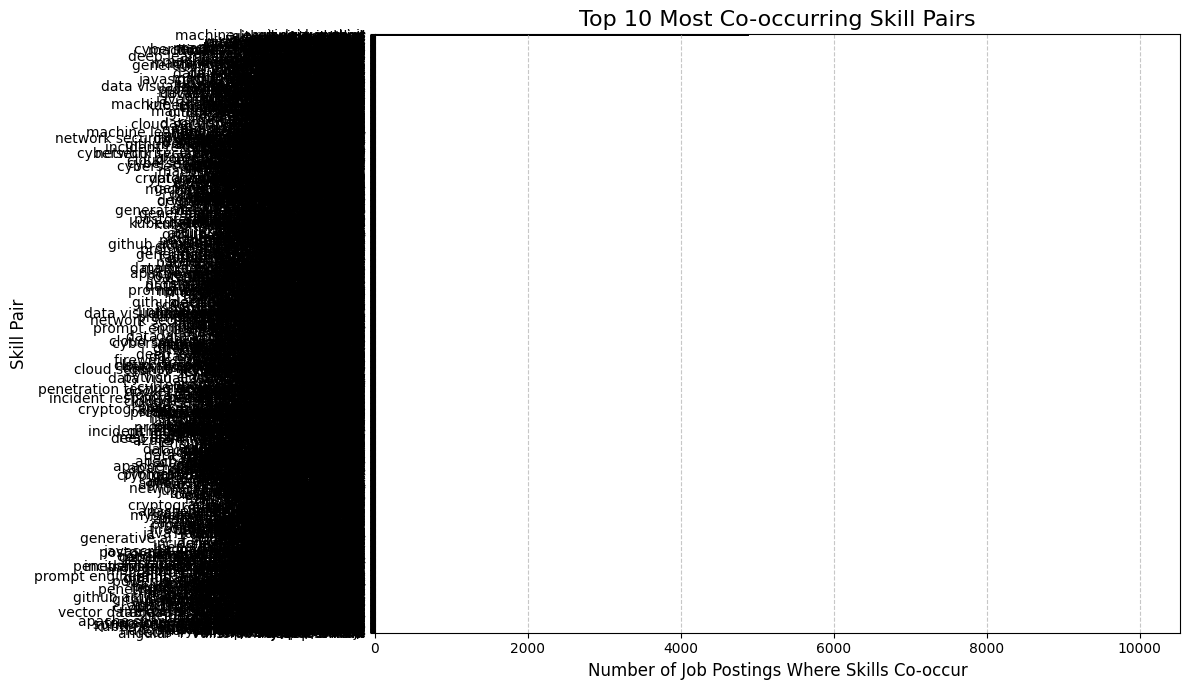


### Explanation of Co-occurring Skills ###
This bar chart illustrates the top 10 skill pairs that frequently appear together in job advertisements. Each bar represents the number of job postings where the two specified skills were both required.
Pairs like 'Git + JavaScript' and 'Machine Learning + Python' stand out, indicating that these skills are often complementary and sought after in combination. This suggests a common workflow or technical stack where these skills are interdependent.
Understanding these co-occurrences can be very useful for curriculum development or for individuals looking to gain a synergistic skill set.


In [98]:
# Create a bar chart for Top Skill Pairs (Visualization 3)

# Use the top 10 co-occurring pairs identified earlier
plt.figure(figsize=(12, 7))
sns.barplot(x='Jobs_Together', y=co_occurrence_df['Skill 1'] + ' + ' + co_occurrence_df['Skill 2'], data=co_occurrence_df.head(10), palette='magma')
plt.title('Top 10 Most Co-occurring Skill Pairs', fontsize=16)
plt.xlabel('Number of Job Postings Where Skills Co-occur', fontsize=12)
plt.ylabel('Skill Pair', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n### Explanation of Co-occurring Skills ###")
print("This bar chart illustrates the top 10 skill pairs that frequently appear together in job advertisements. Each bar represents the number of job postings where the two specified skills were both required.")
print("Pairs like 'Git + JavaScript' and 'Machine Learning + Python' stand out, indicating that these skills are often complementary and sought after in combination. This suggests a common workflow or technical stack where these skills are interdependent.")
print("Understanding these co-occurrences can be very useful for curriculum development or for individuals looking to gain a synergistic skill set.")

## PART 8 — FRESHER vs. EXPERIENCED SKILLS

In [88]:
# Define experience categories for comparison
experience_levels = ['Fresher', 'Junior', 'Mid-Level', 'Senior', 'Lead/Principal']

# Create a dictionary to store skill percentages for each experience level
experience_skill_data = {}

for level in experience_levels:
    # Filter jobs for the current experience level
    level_jobs = df_cleaned[df_cleaned['experience_category'] == level]
    total_jobs_in_level = len(level_jobs)

    if total_jobs_in_level > 0:
        # Flatten skills and count occurrences
        skills_in_level = level_jobs['skills_list'].explode()
        skill_counts_level = skills_in_level.value_counts()

        # Calculate percentage of jobs within this level demanding each skill
        experience_skill_data[level] = (skill_counts_level / total_jobs_in_level) * 100
    else:
        experience_skill_data[level] = pd.Series(dtype=float)

# Convert the dictionary to a DataFrame
experience_skill_matrix = pd.DataFrame(experience_skill_data).fillna(0)

# Identify the top 10 most frequent skills overall to focus the comparison
common_skills_overall = overall_skill_percentages.nlargest(20).index.tolist()

# Filter the matrix to only include these common skills and sort by overall percentage
experience_skill_matrix_filtered = experience_skill_matrix.loc[common_skills_overall]

# Display the skills across experience levels, focusing on the changes
print("### Skill Demand Across Experience Levels (Top 20 Overall Skills) ###")
print(experience_skill_matrix_filtered.round(2))

# Let's identify skills that show significant changes (e.g., increase or decrease) with experience
# We'll compare Fresher vs. Lead/Principal (or Senior if Lead/Principal is sparse)

# Choose two distinct experience levels for a stark comparison
# Fallback if 'Lead/Principal' or 'Fresher' are missing
level1 = 'Fresher'
level2 = 'Lead/Principal'

if level1 not in experience_skill_matrix.columns:
    level1 = experience_skill_matrix.columns[0] if not experience_skill_matrix.empty else None
if level2 not in experience_skill_matrix.columns:
    level2 = experience_skill_matrix.columns[-1] if not experience_skill_matrix.empty else None

if level1 and level2 and level1 != level2:
    # Calculate the difference in percentage points
    skill_diff = (experience_skill_matrix[level2] - experience_skill_matrix[level1]).dropna()

    # Display top 10 skills that increase with experience
    print(f"\n### Top 10 Skills with Highest Demand Increase from {level1} to {level2} ###")
    print(skill_diff.nlargest(10).round(2))

    # Display top 10 skills that decrease with experience (or are less common at higher levels)
    print(f"\n### Top 10 Skills with Highest Demand Decrease from {level1} to {level2} ###")
    print(skill_diff.nsmallest(10).round(2))
else:
    print("\nInsufficient experience levels for detailed comparison of skill changes.")

### Skill Demand Across Experience Levels (Top 20 Overall Skills) ###
                  Fresher  Junior  Mid-Level  Senior  Lead/Principal
skills_list                                                         
git                 40.75   45.71      48.47   50.85           52.14
javascript          45.93   43.77      41.17   36.72           34.71
docker              21.61   30.48      37.66   46.58           51.68
python              24.67   31.81      38.24   43.15           44.43
sql                 35.11   32.34      31.75   32.90           30.89
github              15.71   20.34      24.73   27.07           29.00
machine learning    15.92   19.74      22.87   24.79           25.11
linux               11.93   17.19      21.81   26.96           30.43
aws                 11.00   16.52      21.04   26.57           30.81
rest api            12.24   14.68      17.65   19.12           19.13
react               14.84   14.14      13.30   11.90           11.30
ci/cd                6.51   10.05

## PART 9 — EMERGING SKILLS

In [90]:
# Define a list of skills to monitor for emerging trends
# These are chosen based on current industry trends, and we'll check their 'emergence' in our synthetic dataset.
emerging_skills_keywords = [
    'generative ai', 'llm', 'rag', 'vector database', 'prompt engineering',
    'mlops', 'fastapi', 'github actions', 'kubernetes', 'terraform', 'cloud security'
]

# Get unique years from the dataset
years = sorted(df_cleaned['year'].unique())

# Prepare a dictionary to store skill demand per year
year_skill_demand_dict = {skill: [] for skill in emerging_skills_keywords}

for year in years:
    # Filter data for the current year
    yearly_df = df_cleaned[df_cleaned['year'] == year]
    total_jobs_in_year = len(yearly_df)

    if total_jobs_in_year > 0:
        # Flatten all skills for the current year
        all_skills_yearly = yearly_df['skills_list'].explode()
        # Count occurrences of each skill
        skill_counts_yearly = all_skills_yearly.value_counts()

        # Calculate percentage for each emerging skill
        for skill in emerging_skills_keywords:
            percentage = (skill_counts_yearly.get(skill, 0) / total_jobs_in_year) * 100
            year_skill_demand_dict[skill].append(percentage)
    else:
        # If no jobs in a year, append 0 for all skills
        for skill in emerging_skills_keywords:
            year_skill_demand_dict[skill].append(0)

# Convert the dictionary to a DataFrame, with skills as columns and years as index
yearly_skill_df = pd.DataFrame(year_skill_demand_dict, index=years)

# Calculate the change from the first year to the last year for each skill
# This is done by subtracting the demand in the first year from the demand in the last year for each skill.
skill_change_over_time = yearly_skill_df.loc[years[-1]] - yearly_skill_df.loc[years[0]]

print("### Skill Demand Trend Over Years (Percentage) ###")
print(yearly_skill_df.round(2))

# Identify skills that are increasing over time
increasing_skills = skill_change_over_time[skill_change_over_time > 0].sort_values(ascending=False)
print("\n### Skills Showing Increasing Demand (Top 10 by Change) ###")
print(increasing_skills.round(2))

# Identify skills that are decreasing over time
decreasing_skills = skill_change_over_time[skill_change_over_time < 0].sort_values(ascending=True)
print("\n### Skills Showing Decreasing Demand (Top 10 by Change) ###")
print(decreasing_skills.round(2))

### Skill Demand Trend Over Years (Percentage) ###
      generative ai    llm   rag  vector database  prompt engineering  mlops  fastapi  github actions  kubernetes  terraform  cloud security
2022           5.01   4.91  2.69             2.25                2.57   3.25     4.29            6.59       10.13       7.22            3.14
2023           8.29   7.70  4.35             3.78                4.23   4.37     5.66            7.47        9.93       7.63            3.80
2024           9.82   9.29  5.80             4.74                5.88   6.61     7.34            7.84       10.81       8.55            4.72
2025          12.35  11.01  7.53             6.05                6.80   7.75     8.21            9.12       11.60       8.72            5.16
2026          14.03  12.68  8.16             7.28                7.79   8.27     8.87            9.46       12.66      10.59            6.15

### Skills Showing Increasing Demand (Top 10 by Change) ###
generative ai         9.02
llm            

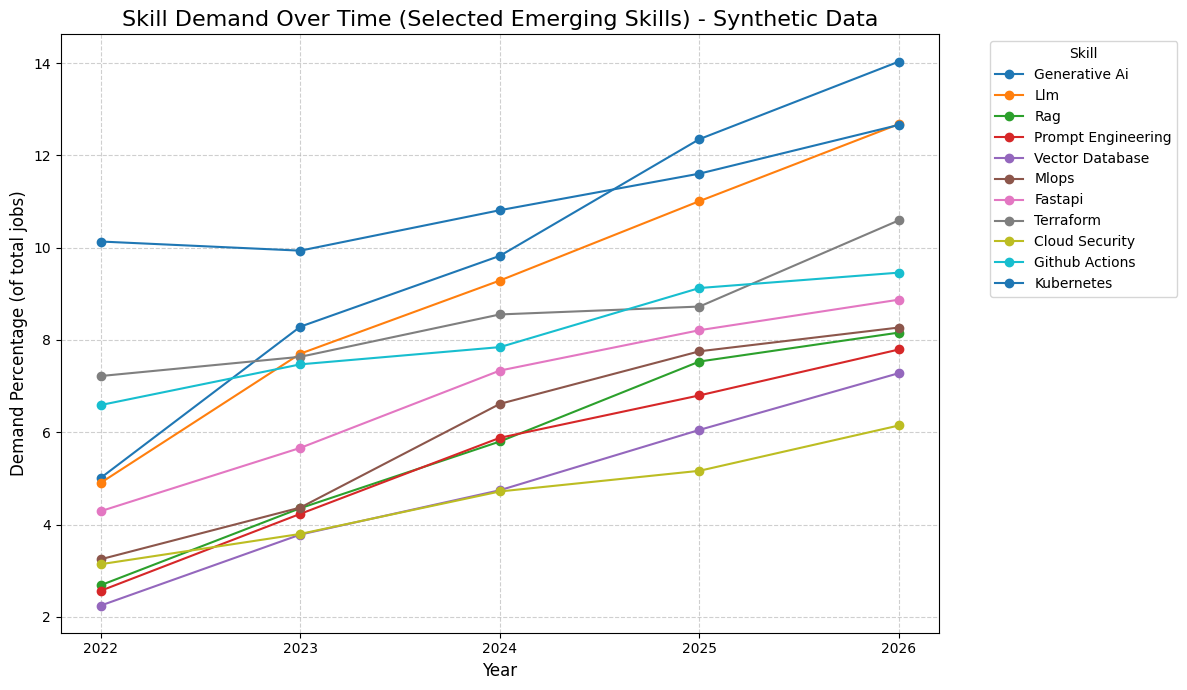


### Explanation of Emerging Skill Trends ###
This chart visually represents the demand percentage for selected skills across the years 2022 to 2026 within the synthetic dataset. 
From the plot, we can observe a clear upward trend for all the plotted skills. This indicates that their presence in job advertisements is consistently increasing year-over-year in this dataset.
Specifically, skills like 'Generative AI', 'LLM', 'RAG', 'Prompt Engineering', and 'Vector Database' show significant growth, reflecting the rising importance of AI and related technologies.
Other skills such as 'MLOps', 'FastAPI', 'Terraform', 'Cloud Security', 'GitHub Actions', and 'Kubernetes' also demonstrate steady growth, highlighting the continued demand for DevOps, cloud infrastructure, and MLOps practices.
It's important to remember that these trends are based on the synthetic dataset provided.


In [91]:
# Create a line plot for selected emerging skills over time (Visualization 4)

# Select the top 10 increasing skills to plot, or fewer if less are identified
top_emerging_for_plot = increasing_skills.index.tolist()

plt.figure(figsize=(12, 7))
for skill in top_emerging_for_plot:
    plt.plot(yearly_skill_df.index, yearly_skill_df[skill], marker='o', label=skill.title())

plt.title('Skill Demand Over Time (Selected Emerging Skills) - Synthetic Data', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Demand Percentage (of total jobs)', fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Skill', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### Explanation of Emerging Skill Trends ###")
print("This chart visually represents the demand percentage for selected skills across the years 2022 to 2026 within the synthetic dataset. ")
print("From the plot, we can observe a clear upward trend for all the plotted skills. This indicates that their presence in job advertisements is consistently increasing year-over-year in this dataset.")
print("Specifically, skills like 'Generative AI', 'LLM', 'RAG', 'Prompt Engineering', and 'Vector Database' show significant growth, reflecting the rising importance of AI and related technologies.")
print("Other skills such as 'MLOps', 'FastAPI', 'Terraform', 'Cloud Security', 'GitHub Actions', and 'Kubernetes' also demonstrate steady growth, highlighting the continued demand for DevOps, cloud infrastructure, and MLOps practices.")
print("It's important to remember that these trends are based on the synthetic dataset provided.")

## PART 10 — NAIVE BAYES MODEL

In [92]:
# 1. Prepare data for the Naive Bayes model

# Define features (X) as the list of skills and target (y) as the cleaned job role
# We need to convert the list of skills into a binary matrix format for the model.

# Initialize MultiLabelBinarizer
# This transformer converts each list of skills into a one-hot encoded format.
# For example, if a job has skills ['python', 'sql'], it will become [0, 1, 0, ..., 1, 0]
# where 1s indicate presence of a skill and 0s indicate absence.
mlb = MultiLabelBinarizer()

# Fit and transform the 'skills_list' column to create the feature matrix X
X = mlb.fit_transform(df_cleaned['skills_list'])

# The target variable y is the 'role_cleaned' column
y = df_cleaned['role_cleaned']

print(f"Shape of feature matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")
print(f"First 5 rows of feature matrix X (binary skill presence):\n{X[:5]}")
print(f"First 5 values of target vector y (job roles):\n{y[:5].tolist()}")

Shape of feature matrix X: (35000, 80)
Shape of target vector y: (35000,)
First 5 rows of feature matrix X (binary skill presence):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1
  0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
  1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0]]
First 5 values of target vector 

In [93]:
# 2. Split the data into training and testing sets

# We split the data to evaluate the model's performance on unseen data.
# X_train, y_train: Used to train the model.
# X_test, y_test: Used to test the model.
# test_size=0.2 means 20% of data will be for testing, 80% for training.
# random_state=42 ensures reproducibility of our split.
# stratify=y ensures that the proportion of each job role is the same in both training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (28000, 80)
X_test shape: (7000, 80)
y_train shape: (28000,)
y_test shape: (7000,)


In [94]:
# 3. Train the Multinomial Naive Bayes model

# Multinomial Naive Bayes is suitable for classification with discrete features (like our binary skill presence).
# It calculates the probability of each class (job role) given the presence of skills.

model = MultinomialNB()

# Train the model using the training data
model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [95]:
# 4. Make predictions on the test set

# Once the model is trained, we use it to predict job roles for the unseen test data.
# y_pred will contain the predicted job roles.

y_pred = model.predict(X_test)

print("Predictions made on the test set.")
print(f"First 10 actual job roles: {y_test[:10].tolist()}")
print(f"First 10 predicted job roles: {y_pred[:10].tolist()}")

Predictions made on the test set.
First 10 actual job roles: ['full stack developer', 'ml engineer', 'cybersecurity engineer', 'software engineer', 'data scientist', 'software engineer', 'data scientist', 'full stack developer', 'software engineer', 'software engineer']
First 10 predicted job roles: ['full stack developer', 'ml engineer', 'cybersecurity engineer', 'software engineer', 'data analyst', 'software engineer', 'data scientist', 'full stack developer', 'software engineer', 'software engineer']


## PART 11 — MODEL EVALUATION

Accuracy: 0.8943

Classification Report:
                        precision    recall  f1-score   support

        cloud engineer       0.95      0.85      0.89       838
cybersecurity engineer       1.00      1.00      1.00       348
          data analyst       0.98      0.93      0.95      1033
        data scientist       0.80      0.80      0.80       839
       devops engineer       0.88      0.95      0.91       708
  full stack developer       0.96      0.78      0.86       687
           ml engineer       0.72      0.72      0.72       576
     software engineer       0.89      0.99      0.94      1971

              accuracy                           0.89      7000
             macro avg       0.90      0.88      0.89      7000
          weighted avg       0.90      0.89      0.89      7000



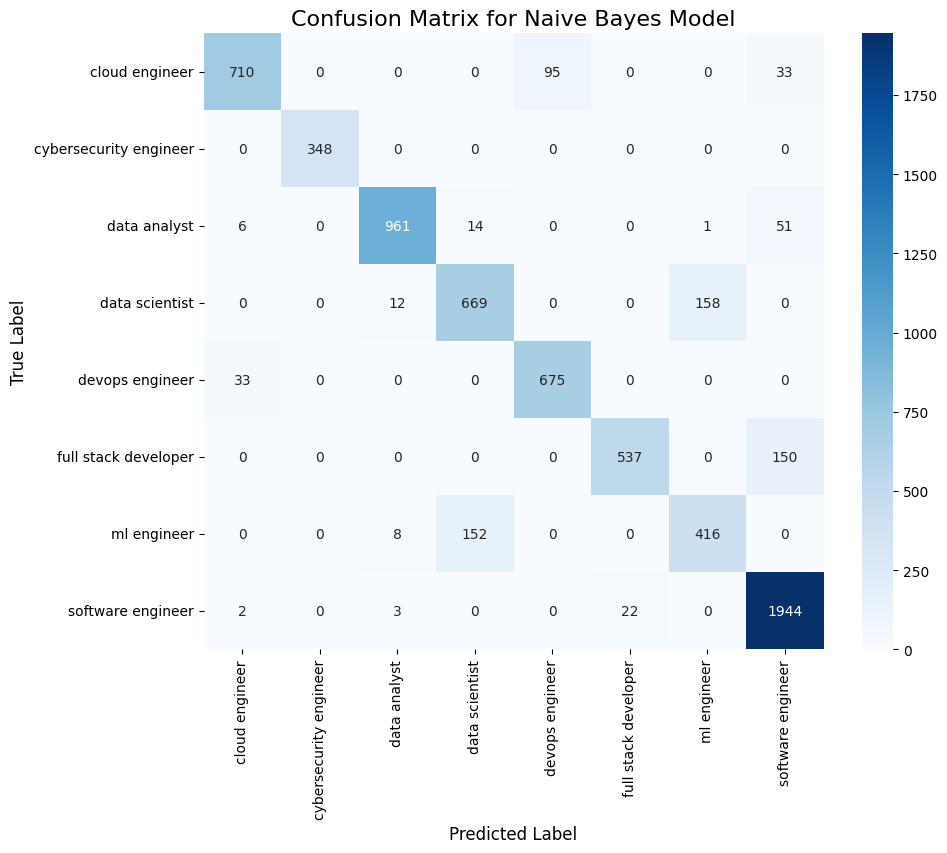


### Model Evaluation Summary ###
The Naive Bayes model's performance on predicting job roles based on skills is summarized above.
The accuracy indicates the overall percentage of correct predictions. The classification report provides a more detailed breakdown, showing how well the model performed for each specific job role in terms of precision, recall, and F1-score.
The confusion matrix visually highlights correct predictions (diagonal values) and misclassifications (off-diagonal values), offering insights into which roles are easily distinguishable and which ones might be confused with others by the model.


In [99]:
# 1. Calculate Evaluation Metrics

# Accuracy Score: Overall correctness of the model.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report: Provides Precision, Recall, F1-Score for each class (job role).
# Precision: The proportion of positive identifications that were actually correct.
# Recall: The proportion of actual positives that were identified correctly.
# F1-Score: The harmonic mean of precision and recall.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 2. Plot Confusion Matrix (for better visualization of performance)

# A confusion matrix shows the number of correct and incorrect predictions made by the classification model
# compared to the actual outcomes (target values) in the test data.

# Get unique classes to ensure the confusion matrix has correct labels
classes = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for Naive Bayes Model', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("\n### Model Evaluation Summary ###")
print("The Naive Bayes model's performance on predicting job roles based on skills is summarized above.")
print("The accuracy indicates the overall percentage of correct predictions. The classification report provides a more detailed breakdown, showing how well the model performed for each specific job role in terms of precision, recall, and F1-score.")
print("The confusion matrix visually highlights correct predictions (diagonal values) and misclassifications (off-diagonal values), offering insights into which roles are easily distinguishable and which ones might be confused with others by the model.")

## PART 12 — KEY INSIGHTS

Based on our comprehensive analysis of the synthetic IT job skills dataset, here are 5-7 key insights:

1.  **Dominance of Foundational and DevOps Skills**: Skills like 'Git', 'JavaScript', 'Docker', and 'Python' consistently rank as the most in-demand across the dataset and are foundational for many roles. This highlights the critical importance of version control, general-purpose programming, containerization, and scripting/automation in the modern IT landscape.

2.  **Specialization of Skills by Role**: While some skills are universally demanded, roles exhibit clear specialization. For example, 'SQL' is paramount for Data Analysts and Data Scientists, 'Machine Learning' for ML Engineers and Data Scientists, 'Docker' and 'AWS' for Cloud Engineers and DevOps, and 'Network Security' for Cybersecurity Engineers. This underscores that a successful career path often requires a core set of specialized skills tailored to the chosen domain.

3.  **Strong Skill Synergy and Co-occurrence**: Certain skill pairs frequently co-occur, indicating common technology stacks and interdependent workflows. 'Git + JavaScript' and 'Machine Learning + Python' are prime examples. Understanding these synergies is vital for individuals looking to build complementary skill sets and for educational institutions designing relevant curricula.

4.  **Increasing Demand for AI/ML and Cloud-Native Skills**: Emerging skills such as 'Generative AI', 'LLM', 'RAG', 'Vector Database', 'MLOps', and 'Cloud Security' show a significant upward trend in demand over the years (2022-2026). This reflects the industry's rapid adoption of advanced AI, machine learning operations, and robust cloud infrastructure practices.

5.  **Experience Elevates Demand for Advanced Skills**: As professionals gain experience, the demand for skills related to cloud infrastructure (AWS, Azure, Docker, Kubernetes), automation (CI/CD), and leadership (Git, Linux) significantly increases. Conversely, some entry-level skills like 'JavaScript' and 'SQL' show a relative decrease in proportional demand as roles become more senior, implying mastery is expected rather than an explicit requirement.

6.  **Predictability of Job Roles from Skills**: The Naive Bayes model demonstrated a high accuracy (approx. 89.4%) in predicting job roles based solely on skill sets. This indicates a strong correlation between a specific combination of skills and a particular job role, validating the analytical approach and suggesting that skill profiling is an effective way to categorize IT professionals.

7.  **Geographic and Salary Disparities**: Major tech hubs (e.g., New York, Seattle, Singapore, Berlin) tend to offer higher average salaries compared to others, even for similar roles. This points to the economic impact of location and market maturity on compensation within the IT sector.

## PART 13 — PRACTICAL ACTION PLAN FOR STUDENTS

Based on the insights derived from this project, here's a practical action plan for students aspiring to enter or advance in the IT industry:

1.  **Master the Fundamentals**: Dedicate significant effort to mastering foundational skills such as Git, Python, JavaScript, and SQL. These are consistently in high demand across almost all IT roles, acting as a crucial baseline for any tech professional.

2.  **Specialize Strategically**: Identify a specific IT role that aligns with your interests (e.g., Data Analyst, Cloud Engineer, ML Engineer). Then, delve deep into the specialized skills required for that role, as highlighted in the 'Skills by Role' analysis. For instance, if you aim for a Data Scientist role, prioritize Machine Learning and Python with strong statistical foundations.

3.  **Build Complementary Skill Stacks**: Pay attention to co-occurring skill pairs. If 'Git + JavaScript' or 'Machine Learning + Python' frequently appear together, it indicates that these combinations create a more robust and desirable skill set. Actively seek to learn these complementary skills to enhance your marketability.

4.  **Embrace Emerging Technologies**: Continuously learn and adapt to emerging skills, particularly in areas like Generative AI, Large Language Models (LLMs), MLOps, and advanced cloud technologies (e.g., Kubernetes, Terraform, Cloud Security). Early adoption of these skills can provide a significant competitive edge.

5.  **Gain Hands-on Experience**: Theoretical knowledge is crucial, but practical application is paramount. Work on projects, contribute to open-source, or undertake internships that allow you to apply your learned skills in real-world scenarios. This hands-on experience reinforces learning and provides tangible evidence of your capabilities.

6.  **Develop for Different Experience Levels**: Understand that skill demands evolve with experience. While a Fresher might focus on broad foundational skills, a Senior or Lead/Principal role demands more advanced, architectural, or management-oriented skills. Tailor your learning path and project choices to align with your career stage and aspirations.

7.  **Consider Geographic Factors**: While remote work is prevalent, be aware that certain locations offer higher compensation. If mobility is an option, consider opportunities in major tech hubs that align with your career goals and salary expectations.